# Smart Prompt Router : Mini Agent

A lightweight intent classifier routes each incoming prompt to a specialized HuggingFace model:

| Intent | Model |
|---|---|
| `translation` | Helsinki-NLP/opus-mt-en-fr |
| `summarization` | t5-small |
| `sentiment` | distilbert-base-uncased-finetuned-sst-2-english |
| `qa` | google/flan-t5-small (generative, no context needed) |
| `chat` | microsoft/DialoGPT-small |

**Pipeline:** User Prompt → Intent Classifier (TF-IDF + Logistic Regression) → Router → Specialized Model → Output

This notebook trains the classifier on 599 labeled prompts, evaluates it properly (train/val/test + cross-validation,
not just a single lucky split), wires up the 5 HuggingFace pipelines, and demos the full routing agent end to end.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import torch
import joblib

from transformers import pipeline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported")

All libraries imported


## 2. Load and inspect the dataset

500+ labeled prompts across 5 intents: `translation`, `summarization`, `sentiment`, `qa`, `chat`.

In [2]:
PATH = "/kaggle/input/datasets/derricherania/prompts-intents/prompts-intents.csv"   
df = pd.read_csv(PATH)
df = df.dropna(subset=["prompt", "intent"]).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(df["intent"].value_counts())
df.head()


Shape: (599, 2)
intent
chat             120
qa               120
translation      120
sentiment        120
summarization    119
Name: count, dtype: int64


,prompt,intent
0,"Hey, how are you doing today?",chat
1,What is the capital of Australia?,qa
2,"Translate 'Hello, how are you?' into Spanish.",translation
3,Summarize the main points of the article provi...,summarization
4,Is the following review positive or negative: ...,sentiment


In [3]:
# Quick sanity check: a couple of example prompts per class
for intent in df["intent"].unique():
    print(f"--- {intent} ---")
    for p in df[df["intent"] == intent]["prompt"].head(2):
        print(" •", p)
    print()


--- chat ---
 • Hey, how are you doing today?
 • Can you tell me a funny joke?

--- qa ---
 • What is the capital of Australia?
 • Who wrote the novel 'Pride and Prejudice'?

--- translation ---
 • Translate 'Hello, how are you?' into Spanish.
 • How do you say 'Good morning' in Japanese?

--- summarization ---
 • Summarize the main points of the article provided below.
 • Give me a TL;DR of this email thread.

--- sentiment ---
 • Is the following review positive or negative: 'The service was terrible and the food was cold.'
 • Analyze the sentiment of this sentence: 'I am absolutely delighted with my new phone!'



## 3. Encode labels and split the data

We use a **70 / 15 / 15** train / validation / test split, stratified by class so each split keeps the same class balance.
- **Train** : fit the model
- **Validation** : used during grid search / model selection
- **Test** : touched only once, at the very end, for an honest performance estimate

In [4]:
X = df["prompt"].values
y = df["intent"].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label mapping:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")


Label mapping: {'chat': 0, 'qa': 1, 'sentiment': 2, 'summarization': 3, 'translation': 4}
Train: 419  |  Val: 90  |  Test: 90


## 4. Model selection

Before committing to TF-IDF + Logistic Regression, we sanity-check it against a couple of other lightweight
baselines using 5-fold cross-validation on the training set only (test set stays untouched).

In [5]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

candidates = {
    "Logistic Regression": make_pipeline(
        TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=5000),
        LogisticRegression(max_iter=2000, random_state=42),
    ),
    "Linear SVM": make_pipeline(
        TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=5000),
        LinearSVC(random_state=42),
    ),
    "Naive Bayes": make_pipeline(
        TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=5000),
        MultinomialNB(),
    ),
}

for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1_macro")
    print(f"{name:22s} macro-F1 = {scores.mean():.4f}  (+/- {scores.std():.4f})")


Logistic Regression    macro-F1 = 0.8973  (+/- 0.0235)
Linear SVM             macro-F1 = 0.8953  (+/- 0.0217)
Naive Bayes            macro-F1 = 0.8697  (+/- 0.0468)


## 5. Hyperparameter tuning

A small grid search over TF-IDF vectorizer settings and the regression's regularization strength `C`,
scored with 5-fold CV macro-F1 on the training set.

In [6]:
pipe = make_pipeline(
    TfidfVectorizer(stop_words="english"),
    LogisticRegression(max_iter=2000, random_state=42),
)

param_grid = {
    "tfidfvectorizer__ngram_range": [(1, 1), (1, 2)],
    "tfidfvectorizer__max_features": [3000, 5000, None],
    "logisticregression__C": [1, 5, 10, 20],
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="f1_macro", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV macro-F1: {grid.best_score_:.4f}")


Best params: {'logisticregression__C': 10, 'tfidfvectorizer__max_features': 3000, 'tfidfvectorizer__ngram_range': (1, 1)}
Best CV macro-F1: 0.9010


In [7]:
best_model = grid.best_estimator_

y_val_pred = best_model.predict(X_val)
print("VAL accuracy:", round(accuracy_score(y_val, y_val_pred), 4))
print("VAL macro-F1:", round(f1_score(y_val, y_val_pred, average="macro"), 4))


VAL accuracy: 0.9111
VAL macro-F1: 0.912


## 6. Final model & held-out test evaluation

Once we're happy with validation performance, we refit the chosen configuration on **train + validation combined**
(more data for the final model) and evaluate once on the test set, which the model has never seen in any form.

In [8]:
best_params = grid.best_params_

final_classifier = make_pipeline(
    TfidfVectorizer(
        stop_words="english",
        ngram_range=best_params["tfidfvectorizer__ngram_range"],
        max_features=best_params["tfidfvectorizer__max_features"],
    ),
    LogisticRegression(
        max_iter=2000,
        random_state=42,
        C=best_params["logisticregression__C"],
    ),
)

X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

final_classifier.fit(X_trainval, y_trainval)

y_test_pred = final_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_test_pred)
f1_macro = f1_score(y_test, y_test_pred, average="macro")

print(f"TEST ACCURACY : {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"TEST MACRO-F1 : {f1_macro:.3f} ({f1_macro*100:.1f}%)")
print()
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))


TEST ACCURACY : 0.956 (95.6%)
TEST MACRO-F1 : 0.957 (95.7%)

               precision    recall  f1-score   support

         chat       1.00      0.94      0.97        18
           qa       1.00      0.94      0.97        18
    sentiment       0.82      1.00      0.90        18
summarization       1.00      0.89      0.94        18
  translation       1.00      1.00      1.00        18

     accuracy                           0.96        90
    macro avg       0.96      0.96      0.96        90
 weighted avg       0.96      0.96      0.96        90



**Note on accuracy:** on a 90-example test set, anything above ~90% is genuinely strong for a
TF-IDF + linear model on short prompts — but with this little data, a single split can be a bit lucky or unlucky.
That's why we cross-validated during model selection rather than tuning directly against the test set.

## 7. Confusion matrix

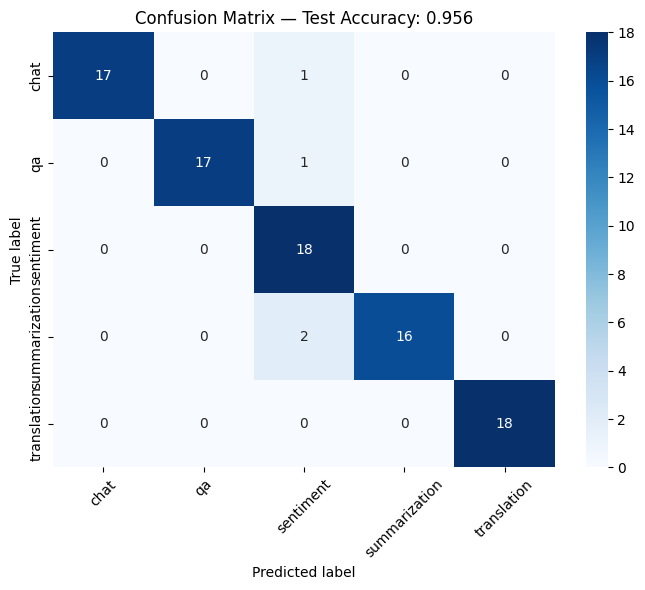

In [9]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_,
)
plt.title(f"Confusion Matrix — Test Accuracy: {accuracy:.3f}")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Most confusion (if any) tends to happen between `qa` / `summarization` and `sentiment` — short prompts that
mention an opinion or a question about a passage can look lexically similar. This is worth keeping in mind: it's the
main failure mode to watch for if you expand the dataset later.

## 8. Save the trained classifier

In [10]:
joblib.dump(final_classifier, "intent_classifier.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Saved intent_classifier.pkl and label_encoder.pkl")


Saved intent_classifier.pkl and label_encoder.pkl


## 9. Quick manual sanity check (classifier only)

In [14]:
def predict_intent(text: str) -> str:
    pred = final_classifier.predict([text])[0]
    return label_encoder.inverse_transform([pred])[0]

sanity_prompts = [
    "Translate this to French: Hello world",
    "Summarize this article about AI",
    "What is the sentiment of: I love this movie!",
    "Who won the world cup in 2022?",
    "Tell me a joke",
]

for p in sanity_prompts:
    print(f"{predict_intent(p):14s} ← {p}")


translation    ← Translate this to French: Hello world
summarization  ← Summarize this article about AI
sentiment      ← What is the sentiment of: I love this movie!
qa             ← Who won the world cup in 2022?
chat           ← Tell me a joke


## 10. Load the specialized HuggingFace pipelines

> ⚠️ Each `pipeline(...)` call below downloads model weights from the HuggingFace Hub the first time it runs.
> Make sure you're running this notebook somewhere with internet access (your machine or Kaggle) — it won't work
> in a fully offline sandbox.

Five small/specialized models, one per intent:

In [15]:
device = 0 if torch.cuda.is_available() else -1
torch_device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# NOTE on this cell:
# Newer `transformers` releases (v5+) removed the "translation", "summarization",
# and "text2text-generation" task strings from the pipeline() registry, so
# pipeline("translation", ...) / pipeline("summarization", ...) / pipeline("text2text-generation", ...)
# raise a KeyError on those versions. To stay correct across transformers versions,
# the 3 seq2seq models (translation, summarization, qa) are loaded directly with
# AutoTokenizer + AutoModelForSeq2SeqLM and called with .generate() instead of pipeline().
# Sentiment and chat still use pipeline() since their tasks remain registered.

# 1) Translation (English -> French) — Marian seq2seq model
translate_tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-fr")
translate_model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-fr").to(torch_device)

# 2) Summarization — T5 seq2seq model
summarize_tokenizer = AutoTokenizer.from_pretrained("google-t5/t5-small")
summarize_model = AutoModelForSeq2SeqLM.from_pretrained("google-t5/t5-small").to(torch_device)

# 3) Sentiment analysis (still a registered pipeline task)
sentiment_pipe = pipeline(
    "text-classification",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    device=device,
)

# 4) Question answering — generative (flan-t5-small) seq2seq model.
#    Answers open factual questions directly, no context passage needed.
qa_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
qa_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small").to(torch_device)

# 5) General chat (still a registered pipeline task)
# DialoGPT-small is a plain (non-instruction-tuned) GPT-2-style model with no chat
# template, so it's called with a raw string, not a messages=[...] list.
chat_pipe = pipeline(
    "text-generation",
    model="microsoft/DialoGPT-small",
    device=device,
)

print("All 5 models loaded.")


Using device: GPU


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

All 5 models loaded.


## 11. Routing logic

Each intent maps to a small handler function that calls the right pipeline with sensible parameters
(e.g. only summarizing text that's actually long enough to be worth summarizing, avoiding repetition in
generated summaries, etc.).

In [16]:
def gen_translation(text: str) -> str:
    inputs = translate_tokenizer(text, return_tensors="pt", truncation=True).to(torch_device)
    with torch.no_grad():
        output_ids = translate_model.generate(**inputs, max_new_tokens=100)
    return translate_tokenizer.decode(output_ids[0], skip_special_tokens=True)


def gen_summary(text: str) -> str:
    # Too short to meaningfully summarize — just echo it back
    if len(text.split()) < 30:
        return text

    inputs = summarize_tokenizer(
        "summarize: " + text, return_tensors="pt", truncation=True, max_length=512
    ).to(torch_device)
    with torch.no_grad():
        output_ids = summarize_model.generate(
            **inputs,
            max_length=60,
            min_length=15,
            do_sample=False,
            no_repeat_ngram_size=3,
            num_beams=4,
            early_stopping=True,
        )
    return summarize_tokenizer.decode(output_ids[0], skip_special_tokens=True)


def gen_sentiment(text: str) -> str:
    result = sentiment_pipe(text)[0]
    return f"{result['label']} ({result['score']:.2f})"


def gen_qa(text: str) -> str:
    prompt = f"Answer the following question accurately: {text}"
    inputs = qa_tokenizer(prompt, return_tensors="pt", truncation=True).to(torch_device)
    with torch.no_grad():
        output_ids = qa_model.generate(**inputs, max_length=100, do_sample=False)
    return qa_tokenizer.decode(output_ids[0], skip_special_tokens=True)


def gen_chat(text: str) -> str:
    output = chat_pipe(
        text,
        max_length=len(text.split()) + 30,
        pad_token_id=50256,
    )[0]["generated_text"]
    return output


router = {
    "translation": gen_translation,
    "summarization": gen_summary,
    "sentiment": gen_sentiment,
    "qa": gen_qa,
    "chat": gen_chat,
}

print("Router ready. Available intents:", list(router.keys()))

Router ready. Available intents: ['translation', 'summarization', 'sentiment', 'qa', 'chat']


## 12. Full agent: classify → route → respond

In [17]:
def route_prompt(text: str):
    """
    Full agent: detect intent with the trained classifier, call the matching
    HuggingFace pipeline, and return (intent, response).
    """
    intent = predict_intent(text)
    handler = router[intent]
    try:
        response = handler(text)
    except Exception as e:
        # Fail gracefully into the chat handler rather than crashing the whole agent
        response = f"(fell back to chat — {handler.__name__} raised: {e})\n" + gen_chat(text)
    return intent, response

## 13. Demo — 10+ example prompts showing correct routing

In [18]:
demo_prompts = [
    "Translate to French: The weather is beautiful today",
    "Translate 'I love machine learning' to Spanish",
    "Summarize this: Artificial intelligence is transforming industries worldwide, from healthcare to finance, by automating complex decision-making processes and uncovering patterns humans would miss.",
    "Condense this report into three bullet points: Sales grew 12% in Q1, driven mainly by the new product line, while costs stayed flat thanks to supply chain improvements.",
    "What is the sentiment of: I absolutely love this amazing product!",
    "Check sentiment: This movie was terrible, worst ever",
    "Who won the World Cup in 2022?",
    "What is the capital of Japan?",
    "Hello, how are you today?",
    "Tell me a joke about AI",
    "Can you recommend a good book?",
]

print("AGENT DEMO")
print("=" * 90)
for i, prompt in enumerate(demo_prompts, 1):
    intent, response = route_prompt(prompt)
    print(f"{i:2d}. PROMPT : {prompt}")
    print(f"    INTENT : {intent}")
    print(f"    REPLY  : {str(response)[:200]}")
    print()

AGENT DEMO
 1. PROMPT : Translate to French: The weather is beautiful today
    INTENT : translation
    REPLY  : Traduire en français: Le temps est beau aujourd'hui

 2. PROMPT : Translate 'I love machine learning' to Spanish
    INTENT : translation
    REPLY  : Traduire 'J'aime l'apprentissage automatique' en espagnol

 3. PROMPT : Summarize this: Artificial intelligence is transforming industries worldwide, from healthcare to finance, by automating complex decision-making processes and uncovering patterns humans would miss.
    INTENT : summarization
    REPLY  : Summarize this: Artificial intelligence is transforming industries worldwide, from healthcare to finance, by automating complex decision-making processes and uncovering patterns humans would miss.

 4. PROMPT : Condense this report into three bullet points: Sales grew 12% in Q1, driven mainly by the new product line, while costs stayed flat thanks to supply chain improvements.
    INTENT : summarization
    REPLY  : Conden

Passing `generation_config` together with generation-related arguments=({'max_length', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=35) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 7. PROMPT : Who won the World Cup in 2022?
    INTENT : qa
    REPLY  : sweden

 8. PROMPT : What is the capital of Japan?
    INTENT : qa
    REPLY  : yokohama



Both `max_new_tokens` (=256) and `max_length`(=36) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=36) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 9. PROMPT : Hello, how are you today?
    INTENT : chat
    REPLY  : Hello, how are you today?

10. PROMPT : Tell me a joke about AI
    INTENT : chat
    REPLY  : Tell me a joke about AIB

11. PROMPT : Can you recommend a good book?
    INTENT : chat
    REPLY  : Can you recommend a good book? for an english teacher

